In [ ]:
from typing import Any, Sequence
from pathlib import Path

import numpy as np
from numpy.typing import NDArray
import matplotlib as mpl
from matplotlib.patches import Rectangle
from matplotlib.figure import Figure
from matplotlib.axes import Axes
import matplotlib.pyplot as plt

RCPARAMS = {
    'font.family': 'sans-serif',
    'font.weight': 'bold',
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
}
mpl.rcParams.update(RCPARAMS)

PLOTPARAMS = {
    # figure
    'size': 6,
    'spacing': 1.25,
    'dpi': 200,
    # plot
    'title_pad': 8,
    'title_fs': 14,
    'label_fs': 12,
    'label_fw': 'bold',
    'alpha': 0.75,
    'grid_color': 'lightgray',
    'grid_ls': '-',
    'grid_lw': 0.2,
    'grid_alpha': 0.7,
    'ticks_w': 2,
    'ticks_len_major': 7,
    'ticks_len_minor': 4,
    'ticks_scilim': (-3, 4),
    # colorbar
    'cbar_origin': 'lower',
    'cbar_shrink': 0.75,
    'cbar_pad': 0.05,
    'cbar_ticks_ls': 11,
    'cbar_label_fs': 12,
    'cbar_label_fw': 'bold',
    'cbar_scilim': (-3, 3),
    # text
    'txt_body_fs': 6,
    'txt_title_fs': 12,
    'txt_fw': 'bold',
    'txt_color': 'black',
}


def _config_subplots(nplots: int) -> tuple[Figure, Axes | list[Axes]]:
    """Creates and configures subplots."""
    size = PLOTPARAMS['size']
    fig_size = (size * nplots + 1, size) if nplots > 1 else (size, size)
    fig, axs = plt.subplots(1, nplots, figsize=fig_size)
    fig.tight_layout()
    fig.dpi = PLOTPARAMS['dpi']
    fig.subplots_adjust(wspace=PLOTPARAMS['spacing'] / size)
    return fig, (axs if nplots > 1 else [axs])

def _config_labels(ax: Axes, xlabel: str | None, ylabel: str | None, title: str) -> None:
    """Configures labels and titles."""
    ax.set_xlabel(
        xlabel=xlabel or '', fontsize=PLOTPARAMS['label_fs'], fontweight=PLOTPARAMS['label_fw'],
    )
    ax.set_ylabel(
        ylabel=ylabel or '', fontsize=PLOTPARAMS['label_fs'], fontweight=PLOTPARAMS['label_fw'],
    )
    ax.set_title(
        label=title, fontsize=PLOTPARAMS['title_fs'],
        pad=PLOTPARAMS['title_pad'], fontweight=PLOTPARAMS['label_fw'],
    )

def _config_ticks(ax: Axes) -> None:
    """Configures grid and tick properties."""
    ax.grid(
        visible=True, color=PLOTPARAMS['grid_color'], linestyle=PLOTPARAMS['grid_ls'],
        linewidth=PLOTPARAMS['grid_lw'], alpha=PLOTPARAMS['grid_alpha'],
    )
    ax.xaxis.set_ticks_position('both')
    ax.yaxis.set_ticks_position('both')
    ax.tick_params(
        which='both', direction='in', width=PLOTPARAMS['ticks_w'],
        length=PLOTPARAMS['ticks_len_major'] if 'major' else PLOTPARAMS['ticks_len_minor'],
    )
    ax.ticklabel_format(scilimits=PLOTPARAMS['ticks_scilim'])

def _config_view(
    ax: Axes,
    xlim: tuple[Any, Any],
    ylim: tuple[Any, Any],
    xscale: str,
    yscale: str,
) -> None:
    """Configures axes limits and scales."""
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.set_xscale(xscale)
    ax.set_yscale(yscale)




def SetUpMap4biplot(
    arrs: NDArray | Sequence[NDArray],
    title: str,
    *,
    xlabel: str | None = None,
    ylabel: str | None = None,
    labels: str | Sequence[str | None] | None = None,
    x: NDArray | Sequence[NDArray] | None = None,
    style: str | Sequence[str] | None = None,
    color: str | tuple[str, str] | Sequence[str | tuple[str, str]] | None = None,
    xlim: tuple[Any, Any] | Sequence[tuple[Any, Any]] | None = None,
    ylim: tuple[Any, Any] | Sequence[tuple[Any, Any]] | None = None,
    xscale: str | Sequence[str | None] | None = None,
    yscale: str | Sequence[str | None] | None = None,
) -> dict[str, Any]:
    """
    
    """
    arrs_ = (arrs,) if isinstance(arrs, np.ndarray) else tuple(arrs)
    x_ = (
        (x,) if isinstance(x, np.ndarray)
        else tuple(np.arange(len(a)) for a in arrs_)
    )
    N_PLOTS = len(arrs_)

    def setup(x: Any, *, dtype: Any, default: Any) -> tuple[Any]:
        """Setup variables for plotting."""
        if x is None:
            return (default,) * N_PLOTS
        elif isinstance(x, dtype):
            return (x,) * N_PLOTS
        return tuple(x)
    
    dmap = {
        'arrs': arrs_,
        'title': title,
        'xlabel': xlabel,
        'ylabel': ylabel,
        'labels': setup(labels, dtype=str, default=None),
        'x': x_,
        'style': setup(style, dtype=str, default='plot'),
        'color': setup(color, dtype=str, default=None),
        'xlim': xlim or (None, None),
        'ylim': ylim or (None, None),
        'xscale': xscale or 'linear',
        'yscale': yscale or 'linear',
    }
    return dmap


def biplot(
    dmap_A: dict[str, Any],
    dmap_B: dict[str, Any],
    save_to: str | Path | None = None,
    **kwargs,
) -> None:
    """
    
    """
    fig, axs = _config_subplots(2)
    for ax, dmap in zip(axs, (dmap_A, dmap_B)):
        _config_labels(ax, dmap['xlabel'], dmap['ylabel'], dmap['title'])
        _config_ticks(ax)
        
        for idx, arr in enumerate(dmap['arrs']):
            match dmap['style'][idx]:
                case 'plot':
                    ax.plot(
                        dmap['x'][idx], arr, c=dmap['color'][idx], alpha=0.75,
                        label=dmap['labels'][idx], **kwargs,
                    )
                case 'scatter':
                    c = dmap['color'][idx]
                    fcolor, ecolor = c if isinstance(c, tuple) else (c, c)
                    ax.scatter(
                        dmap['x'][idx], arr, c=fcolor, edgecolors=ecolor, s=60, alpha=0.75,
                        linewidths=1.5, label=dmap['labels'][idx], **kwargs,
                    )
                case 'bar':
                    raise NotImplementedError
        
        _config_view(
            ax, dmap['xlim'], dmap['ylim'], dmap['xscale'], dmap['yscale'],
        )
        if any(dmap['labels']): ax.legend(loc='best')
    
    if save_to is not None: plt.savefig(save_to)
    plt.show()

In [2]:
dmap1 = SetUpMap4biplot(
    arrs=np.random.randint(0, 10, 10),
    title='test',
    xlabel='x',
    ylabel='y',
    style='scatter',
)

dmap2 = SetUpMap4biplot(
    arrs=(
        np.random.randint(0, 10, 10),
        np.random.randint(0, 10, 10),
    ),
    title='test',
    xlabel='x',
    ylabel='y',
    style=('scatter', 'scatter'),
)

dmap1, dmap2

({'arrs': (array([9, 9, 1, 2, 9, 0, 8, 8, 6, 6]),),
  'title': 'test',
  'xlabel': 'x',
  'ylabel': 'y',
  'labels': (None,),
  'x': (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),),
  'style': ('scatter',),
  'color': (None,),
  'xlim': (None, None),
  'ylim': (None, None),
  'xscale': 'linear',
  'yscale': 'linear'},
 {'arrs': (array([1, 9, 7, 4, 3, 3, 1, 1, 4, 5]),
   array([2, 0, 4, 8, 0, 6, 0, 3, 4, 7])),
  'title': 'test',
  'xlabel': 'x',
  'ylabel': 'y',
  'labels': (None, None),
  'x': (array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
   array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])),
  'style': ('scatter', 'scatter'),
  'color': (None, None),
  'xlim': (None, None),
  'ylim': (None, None),
  'xscale': 'linear',
  'yscale': 'linear'})

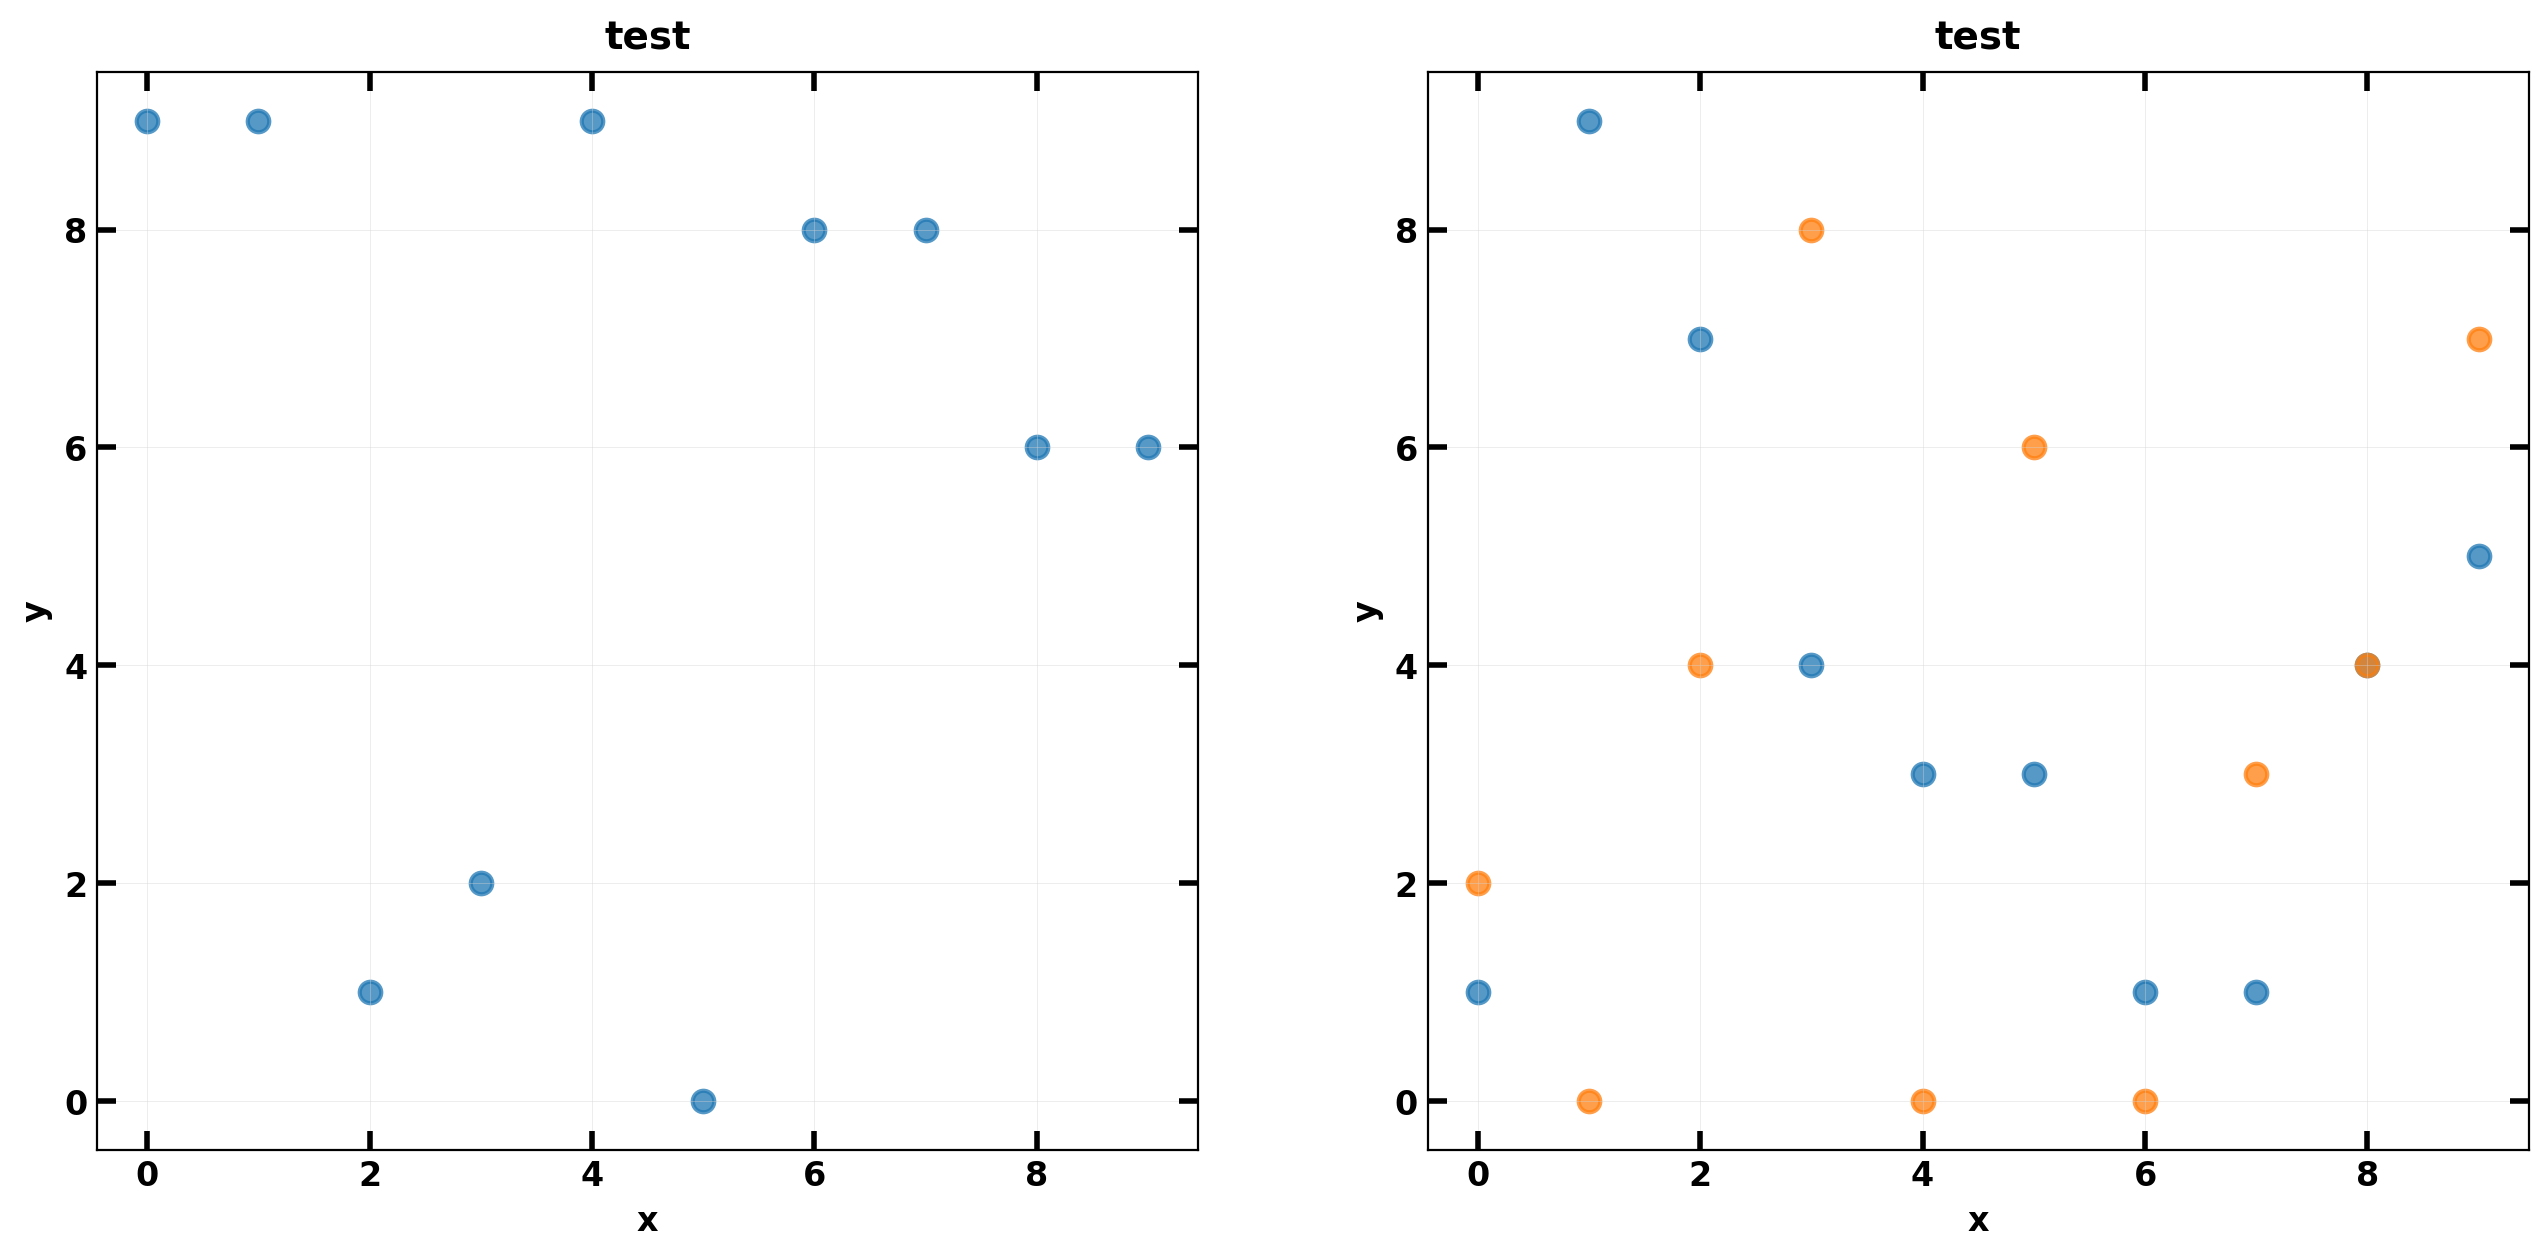

In [3]:
biplot(dmap1, dmap2)

In [4]:
assert False

def SetUpMap4biplot(
    arrs: NDArray | Sequence[NDArray],
    title: str,
    *,
    xlabel: str | None = None,
    ylabel: str | None = None,
    labels: str | Sequence[str | None] | None = None,
    x: NDArray | Sequence[NDArray] | None = None,
    style: str | Sequence[str] | None = None,
    color: str | tuple[str, str] | Sequence[str | tuple[str, str]] | None = None,
    xlim: tuple[Any, Any] | Sequence[tuple[Any, Any]] | None = None,
    ylim: tuple[Any, Any] | Sequence[tuple[Any, Any]] | None = None,
    xscale: str | Sequence[str | None] | None = None,
    yscale: str | Sequence[str | None] | None = None,
) -> dict[str, Any]:
    """
    
    """
    def setup(x: Any, dtype: Any) -> tuple[Any]:
        """Setup variable for plotting."""
        return (
            (x,) if isinstance(x, dtype) else x
        )
    
    def default(x: Any) -> tuple[Any]:
        """Initializes default values."""
        return (
            (x,) if isinstance(arrs, np.ndarray)
            else (x,) * len(arrs)
        )
    
    arrs_ = setup(arrs, np.ndarray)
    dmap = {
        'arrs': arrs_,
        'title': title,
        'xlabel': xlabel,
        'ylabel': ylabel,
        'labels': labels or default(None),
        'x': setup(x, np.ndarray) or tuple(np.arange(len(a)) for a in arrs_),
        'style': setup(style, str) or default('plot'),
        'color': setup(color, str) or default(None),
        'xlim': xlim or (None, None),
        'ylim': ylim or (None, None),
        'xscale': xscale or 'linear',
        'yscale': yscale or 'linear',
    }
    return dmap


def SetUpMap4biplot(
    arrs: NDArray | Sequence[NDArray],
    title: str,
    *,
    xlabel: str | None = None,
    ylabel: str | None = None,
    labels: str | Sequence[str | None] | None = None,
    x: NDArray | Sequence[NDArray] | None = None,
    style: str | Sequence[str] | None = None,
    color: str | tuple[str, str] | Sequence[str | tuple[str, str]] | None = None,
    xlim: tuple[Any, Any] | Sequence[tuple[Any, Any]] | None = None,
    ylim: tuple[Any, Any] | Sequence[tuple[Any, Any]] | None = None,
    xscale: str | Sequence[str | None] | None = None,
    yscale: str | Sequence[str | None] | None = None,
) -> dict[str, Any]:
    """"""
    arrs_ = (arrs,) if isinstance(arrs, np.ndarray) else tuple(arrs)
    n_plots = len(arrs_)

    if x is None:
        x_ = tuple(np.arange(len(arr)) for arr in arrs_)
    elif isinstance(x, np.ndarray):
        x_ = (x,) * n_plots
    else:
        x_ = tuple(x)

    def _normalize(param: Any, default: Any, is_single_type: type) -> tuple:
        """Helper to broadcast single values or apply defaults."""
        if param is None:
            return (default,) * n_plots
        if isinstance(param, is_single_type):
            return (param,) * n_plots
        return tuple(param)

    return {
        'arrs': arrs_,
        'title': title,
        'xlabel': xlabel,
        'ylabel': ylabel,
        'labels': _normalize(labels, default=None, is_single_type=str),
        'x': x_,
        'style': _normalize(style, default='plot', is_single_type=str),
        'color': _normalize(color, default=None, is_single_type=str),
        'xlim': _normalize(xlim, default=None, is_single_type=tuple),
        'ylim': _normalize(ylim, default=None, is_single_type=tuple),
        'xscale': _normalize(xscale, default='linear', is_single_type=str),
        'yscale': _normalize(yscale, default='linear', is_single_type=str),
    }

AssertionError: 

In [ ]:
assert False

from IROS._pipeline_support import _handle_dirpaths
import matplotlib.pyplot as plt

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask, count
from darksun.data import get_data

skyfield = "GalacticCenter"

mask_FITS = "wfm_mask_summer2021.fits"
data_FITS = "galctr_rxte-sax_mask_summer2021_infdet_2-50keV_1ks"

N_TEST = "testing"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

UPX, UPY = 1, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1b"
dataset = 'reconstructed'

filepaths = simulation_files(simul_data)
sdlA = get_data(filepaths[cam_a][dataset])

detector_counts, bins = count(wfm, sdlA.data)
plt.imshow(detector_counts); plt.show()

AssertionError: 